In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [7]:
DATASET_PATH = "/kaggle/input/datasets/azminur2856/alzheimer-mri-dataset/Data"

In [3]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=seed
)

val_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 32000 images belonging to 4 classes.
Found 8000 images belonging to 4 classes.


In [4]:
def attention_block(x):
    attention = layers.GlobalAveragePooling2D()(x)
    attention = layers.Dense(x.shape[-1], activation='sigmoid')(attention)
    attention = layers.Reshape((1,1,x.shape[-1]))(attention)
    return layers.multiply([x, attention])

In [8]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = layers.Conv2D(256, (1,1), activation='relu')(x)
x = attention_block(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(4, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,245,892 (92.49 MB)

 Trainable params: 657,668 (2.51 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [9]:
lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [12]:
class_weight = {0:1.0, 1:1.2, 2:1.5, 3:2.0}

In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, lr_schedule],
    class_weight=class_weight
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1776490075.874783     139 service.cc:152] XLA service 0x7ac51c0037a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776490075.874843     139 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776490078.321850     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/1000 ━━━━━━━━━━━━━━━━━━━━ 54s 54ms/step - accuracy: 0.2266 - loss: 3.0157   

I0000 00:00:1776490083.646957     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 781s 765ms/step - accuracy: 0.4811 - loss: 1.7011 - val_accuracy: 0.6489 - val_loss: 0.7783 - learning_rate: 1.0000e-04
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 552s 553ms/step - accuracy: 0.6515 - loss: 1.0978 - val_accuracy: 0.6991 - val_loss: 0.6660 - learning_rate: 1.0000e-04
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 519s 519ms/step - accuracy: 0.6999 - loss: 0.9670 - val_accuracy: 0.7326 - val_loss: 0.6108 - learning_rate: 1.0000e-04
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 516s 516ms/step - accuracy: 0.7370 - loss: 0.8741 - val_accuracy: 0.7742 - val_loss: 0.5264 - learning_rate: 1.0000e-04
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 519s 519ms/step - accuracy: 0.7565 - loss: 0.8061 - val_accuracy: 0.7856 - val_loss: 0.5079 - learning_rate: 1.0000e-04
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 506s 506ms/step - accuracy: 0.7751 - loss: 0.7443 - val_accuracy: 0.8092 - val_loss: 0.4550 - learning_rate: 1.0000e-04
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━

In [18]:
for layer in base_model.layers[-60:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history_fine2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop, lr_schedule],
    class_weight=class_weight
)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 553s 524ms/step - accuracy: 0.9069 - loss: 0.3574 - val_accuracy: 0.9379 - val_loss: 0.1632 - learning_rate: 5.0000e-06
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 512s 512ms/step - accuracy: 0.9344 - loss: 0.2586 - val_accuracy: 0.9480 - val_loss: 0.1411 - learning_rate: 5.0000e-06
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 515s 515ms/step - accuracy: 0.9432 - loss: 0.2250 - val_accuracy: 0.9580 - val_loss: 0.1178 - learning_rate: 5.0000e-06
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 505s 505ms/step - accuracy: 0.9513 - loss: 0.1959 - val_accuracy: 0.9584 - val_loss: 0.1080 - learning_rate: 5.0000e-06
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 491s 491ms/step - accuracy: 0.9585 - loss: 0.1742 - val_accuracy: 0.9619 - val_loss: 0.1007 - learning_rate: 5.0000e-06


In [16]:
model.save('/kaggle/working/best_model.h5')

In [21]:
model.save('/kaggle/working/final_model_96_1.h5')

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [24]:
img_path = "/kaggle/input/datasets/azminur2856/alzheimer-mri-dataset/Data/MildDemented/MRI-MD-09266.jpg"

In [25]:
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))
img_array = np.expand_dims(img, axis=0)
img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

In [26]:
last_conv_layer = model.get_layer("conv5_block3_out")

In [28]:
grad_model = tf.keras.models.Model(
    [model.inputs],
    [last_conv_layer.output, model.output]
)

In [29]:
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    class_idx = np.argmax(predictions[0])
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_185']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


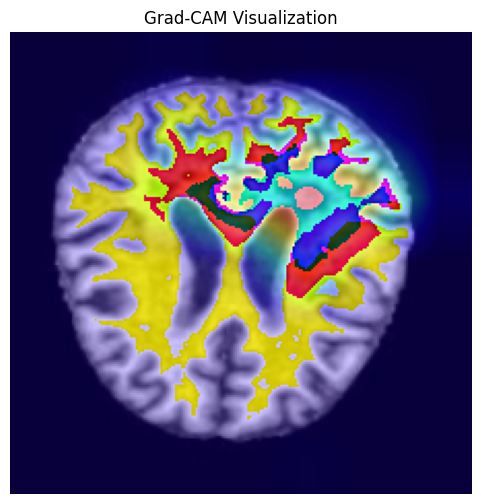

In [30]:
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Grad-CAM Visualization")
plt.show()

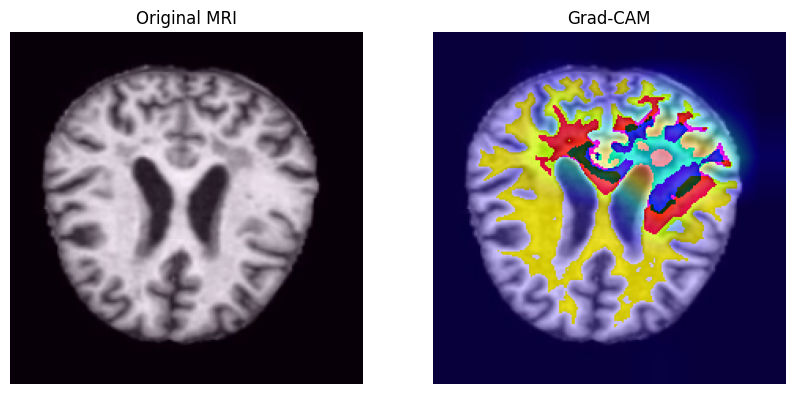

In [31]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original MRI")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM")
plt.axis('off')

plt.show()